# Feature Attribution with SHAP
### Which features does the model actually rely on, and is that stable across people?

**Purpose.** The mechanism decomposition established *causally* that residual features carry the
performance gain: removing them and retraining costs +0.096 macro-F1, while removing the MESOR term
costs only +0.007. This notebook asks a complementary question — inside a single trained model,
which features does it actually *use*?

**These are different questions and must not be confused.**

| | Decomposition (already done) | SHAP (this notebook) |
|---|---|---|
| Method | Remove features, retrain, measure loss | Attribute one model's outputs to its inputs |
| Question | Does the model *need* this feature? | Does the model *use* this feature? |
| Evidence type | Causal | Descriptive |
| Handles correlated features | Yes — retraining lets others compensate | Poorly — credit gets split among correlates |

A feature can show high SHAP importance yet be causally unnecessary, because a correlated feature
would substitute for it if it were removed. The decomposition remains the primary evidence; SHAP adds
an interpretable view of the same model and produces a figure suitable for publication.

**What is produced.**

1. Group-level attribution (HRV / residual / MESOR / circadian) — the visual companion to Table I.
2. Per-feature ranking with the top contributors named.
3. **Attribution stability across subjects** — whether the model relies on the same features for
   every person, which speaks directly to whether a single population model is appropriate.

**Honest expectation.** SHAP should show residual features carrying substantial weight and MESOR
carrying little, echoing the decomposition. If MESOR shows high SHAP importance despite contributing
+0.007 causally, that is itself worth reporting — it would mean the model uses a feature it does not
need, which is exactly the correlated-feature effect described above.


## 1. Setup

In [1]:
!pip install neurokit2 shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.6 MB/s eta 0:00:00


In [2]:
import os, json, pickle, warnings, time
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import welch
from scipy.stats import spearmanr
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import shap, neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42)

DATA_PATH='/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
SUBJECT_IDS=[2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES=['relaxed','mild','moderate','high']; NCLS=4
WINDOW=120; STEP=5
print("shap",shap.__version__)

shap 0.51.0


## 2. Pipeline and the 25-feature vector

In [3]:
FEATURE_NAMES=[
 # --- HRV block (13) ---
 'mean_RR','SDNN','RMSSD','pNN50','CV_RR','VLF','LF','HF','LF/HF','LF_nu','SD1','SD2','SD1/SD2',
 # --- residual block (5) ---
 'res_mean','res_SD','res_maxabs','res_meandiff','res_slope',
 # --- Cosinor parameters (2) ---
 'MESOR','amplitude',
 # --- circadian/time encodings (5) ---
 'sin_24h','cos_24h','sin_90m','cos_90m','cortisol_proxy']
assert len(FEATURE_NAMES)==25

GROUPS={'HRV (13)':list(range(0,13)),
        'Residual (5)':list(range(13,18)),
        'MESOR (2)':[18,19],
        'Circadian (5)':list(range(20,25))}
GROUP_COLOR={'HRV (13)':'#8C8C8C','Residual (5)':'#C44E52',
             'MESOR (2)':'#4C72B0','Circadian (5)':'#55A868'}
print({k:len(v) for k,v in GROUPS.items()})

{'HRV (13)': 13, 'Residual (5)': 5, 'MESOR (2)': 2, 'Circadian (5)': 5}


In [4]:
def load_subject(sid):
    with open(f"{DATA_PATH}/S{sid}/S{sid}.pkl",'rb') as f: d=pickle.load(f,encoding='latin1')
    return d['signal']['chest'], d['signal']['wrist']['TEMP'].flatten(), d['label'].flatten()
def extract_rr(ecg,fs=700):
    ecg=nk.ecg_clean(ecg.flatten(),sampling_rate=fs); _,i=nk.ecg_peaks(ecg,sampling_rate=fs); rp=i['ECG_R_Peaks']
    return np.diff(rp)*(1000.0/fs),(rp[:-1]+rp[1:])/2.0/fs,rp
def clean_rr(rr,ts):
    rr=rr.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr,ts
def align_temp(wt,rp,fe=700,ft=4.0):
    tap=np.interp(rp/fe,np.arange(len(wt))/ft,wt); return (tap[:-1]+tap[1:])/2.0
def labels_to_rr(labels,rp):
    o=[]
    for i in range(len(rp)-1):
        seg=labels[rp[i]:rp[i+1]]; v=seg[seg>0]; o.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(o)
def cos_model(th,M,A,P): return M+A*np.cos((2*np.pi/24.0)*th+P)
def fit_cos(sig,ts,p0):
    th=(ts%86400)/3600.0
    try:
        popt,_=curve_fit(cos_model,th,sig,p0=p0,maxfev=10000)
        return sig-cos_model(th,*popt),popt[0],popt[1]
    except RuntimeError:
        return sig-np.mean(sig),float(np.mean(sig)),0.0

wesad={}
for sid in SUBJECT_IDS:
    try:
        chest,wt,labels=load_subject(sid); ecg=chest['ECG'].flatten()
        rr,ts,rp=extract_rr(ecg); temp=align_temp(wt,rp); rr,ts=clean_rr(rr,ts)
        rl=labels_to_rr(labels,rp); keep=rl>0
        rrk,tk,tsk,lk=rr[keep],temp[keep],ts[keep],rl[keep]
        new=np.zeros(len(lk),dtype=int); si=np.where(lk==2)[0]
        if len(si)>0:
            srr=rrk[si]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w); loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(si): new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        res,mesor,amp=fit_cos(rrk,tsk,[np.mean(rrk),50,-1.5])
        wesad[f'S{sid}']=dict(rr_ms=rrk,temp=tk,timestamps=tsk,labels=new,
                              res=res,mesor=mesor,amp=amp)
    except Exception as e: print("FAIL",sid,e)
print(len(wesad),"subjects"); assert len(wesad)==15

15 subjects


In [5]:
def hrv_features(rr):
    dd=np.diff(rr); nn=len(rr)
    rmssd=np.sqrt(np.mean(dd**2)) if nn>1 else 0.0
    sdnn=np.std(rr); mean_rr=np.mean(rr)
    pnn50=np.mean(np.abs(dd)>50)*100 if nn>1 else 0.0
    cv=sdnn/(mean_rr+1e-8)
    try:
        fs=4.0; t=np.cumsum(rr)/1000.0
        ti=np.arange(t[0],t[-1],1/fs); ri=np.interp(ti,t,rr)
        f,pxx=welch(ri-np.mean(ri),fs=fs,nperseg=min(256,len(ri)))
        band=lambda lo,hi: TRAPZ(pxx[(f>=lo)&(f<hi)],f[(f>=lo)&(f<hi)]) if np.any((f>=lo)&(f<hi)) else 0.0
        vlf,lf,hf=band(0.003,0.04),band(0.04,0.15),band(0.15,0.4)
    except Exception: vlf=lf=hf=0.0
    tot=lf+hf+1e-8
    sd1=np.sqrt(0.5)*np.std(dd) if nn>1 else 0.0
    sd2=np.sqrt(max(2*sdnn**2-0.5*np.std(dd)**2,0)) if nn>1 else 0.0
    return np.array([mean_rr,sdnn,rmssd,pnn50,cv,vlf,lf,hf,lf/(hf+1e-8),lf/tot,sd1,sd2,sd1/(sd2+1e-8)])

def resid_features(r):
    dd=np.diff(r)
    return np.array([np.mean(r),np.std(r),np.max(np.abs(r)),
                     np.mean(np.abs(dd)) if len(dd)>0 else 0.0,
                     np.polyfit(np.arange(len(r)),r,1)[0]])

def circ_features(t):
    tt=t%86400; hour=tt/3600.0
    return np.array([np.sin(2*np.pi*tt/86400),np.cos(2*np.pi*tt/86400),
                     np.sin(2*np.pi*tt/5400),np.cos(2*np.pi*tt/5400),
                     0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2)])

X,y,g=[],[],[]
for sid,d in wesad.items():
    rr,ts,lab,res=d['rr_ms'],d['timestamps'],d['labels'],d['res']
    for s in range(0,len(rr)-WINDOW,STEP):
        e=s+WINDOW; bi=min(s+WINDOW//2,len(ts)-1)
        X.append(np.concatenate([hrv_features(rr[s:e]),resid_features(res[s:e]),
                                 np.array([d['mesor'],d['amp']]),circ_features(ts[bi])]))
        y.append(lab[s+WINDOW//2]); g.append(int(sid[1:]))
X=np.array(X,np.float32); y=np.array(y,int); g=np.array(g,int)
print("X",X.shape,"| classes",np.bincount(y))
assert X.shape[1]==25

X (11846, 25) | classes [8594 1101 1080 1071]


## 3. Computing SHAP values under leave-one-subject-out

One model is trained per fold and explained on that fold's held-out subject. This keeps the
attribution honest: the model never saw the data it is being explained on.

SHAP's output shape varies by version for multiclass models — either `(n, features, classes)` or a
list of per-class arrays. The helper below normalises both.

In [6]:
def normalise_shap(sv, n_feat):
    """Return array of shape (n_samples, n_features, n_classes) from either format."""
    if isinstance(sv,list):
        return np.stack(sv,axis=-1)
    sv=np.asarray(sv)
    if sv.ndim==3:
        return sv if sv.shape[1]==n_feat else np.transpose(sv,(0,2,1))
    if sv.ndim==2:
        return sv[:,:,None]
    raise ValueError(f"unexpected SHAP shape {sv.shape}")

logo=LeaveOneGroupOut()
per_subject_imp={}      # subject -> (25,) mean |SHAP|
shap_pool, X_pool, y_pool = [], [], []
t0=time.time()

for tr,te in logo.split(X,y,g):
    s=int(np.unique(g[te])[0]); print(f"S{s:02d}",end=' ',flush=True)
    mdl=XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                      subsample=0.9,colsample_bytree=0.9,
                      objective='multi:softprob',num_class=NCLS,
                      tree_method='hist',eval_metric='mlogloss',verbosity=0)
    mdl.fit(X[tr],y[tr],sample_weight=compute_sample_weight('balanced',y[tr]))

    expl=shap.TreeExplainer(mdl)
    sv=normalise_shap(expl.shap_values(X[te]),X.shape[1])
    per_subject_imp[s]=np.abs(sv).mean(axis=(0,2))          # (25,)

    k=min(400,len(te))                                       # subsample for pooled plots
    sel=np.random.RandomState(0).choice(len(te),k,replace=False)
    shap_pool.append(sv[sel]); X_pool.append(X[te][sel]); y_pool.append(y[te][sel])

SHAP=np.concatenate(shap_pool,0); XP=np.concatenate(X_pool,0); YP=np.concatenate(y_pool,0)
print(f"\nSHAP array {SHAP.shape}   ({(time.time()-t0)/60:.1f} min)")
np.save(f'{SAVE}/shap_values.npy',SHAP); np.save(f'{SAVE}/shap_X.npy',XP)

S02 S03 S04 S05 S06 S07 S08 S09 S10 S11 S13 S14 S15 S16 S17 
SHAP array (6000, 25, 4)   (1.5 min)


## 4. Group-level attribution — the companion to Table I

Mean absolute SHAP value summed within each feature group, expressed as a share of total
attribution. This is the figure most suitable for the paper.

GROUP-LEVEL ATTRIBUTION
group               share   per-feature   causal gain (Table I)
--------------------------------------------------------------
HRV (13)           27.0%        0.1053   baseline
Residual (5)       29.7%        0.3010   +0.096
MESOR (2)           4.1%        0.1036   +0.007
Circadian (5)      39.3%        0.3984   +0.087*
--------------------------------------------------------------
* circadian encodings are part of the HRV+time baseline, not an increment


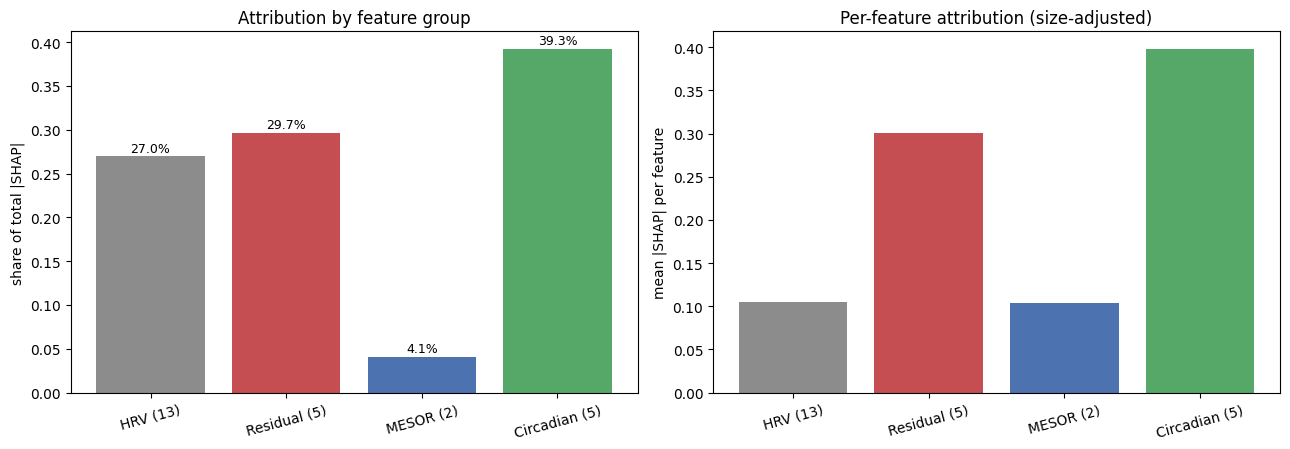


saved fig_shap_groups.png

Note: HRV has 13 features and MESOR only 2, so the right-hand panel
(per-feature) is the fairer comparison of individual feature strength.


In [7]:
imp=np.abs(SHAP).mean(axis=(0,2))               # (25,)
gimp={k:float(imp[idx].sum()) for k,idx in GROUPS.items()}
tot=sum(gimp.values())
share={k:v/tot for k,v in gimp.items()}

print("="*62); print("GROUP-LEVEL ATTRIBUTION"); print("="*62)
print(f"{'group':<16}{'share':>9}{'per-feature':>14}   causal gain (Table I)")
print("-"*62)
ref={'HRV (13)':'baseline','Residual (5)':'+0.096','MESOR (2)':'+0.007','Circadian (5)':'+0.087*'}
for k in GROUPS:
    print(f"{k:<16}{share[k]:>8.1%}{gimp[k]/len(GROUPS[k]):>14.4f}   {ref[k]}")
print("-"*62)
print("* circadian encodings are part of the HRV+time baseline, not an increment")

fig,ax=plt.subplots(1,2,figsize=(13,4.6))
ks=list(GROUPS)
ax[0].bar(ks,[share[k] for k in ks],color=[GROUP_COLOR[k] for k in ks])
ax[0].set_ylabel('share of total |SHAP|'); ax[0].set_title('Attribution by feature group')
ax[0].tick_params(axis='x',rotation=15)
for i,k in enumerate(ks): ax[0].text(i,share[k]+.005,f"{share[k]:.1%}",ha='center',fontsize=9)
ax[1].bar(ks,[gimp[k]/len(GROUPS[k]) for k in ks],color=[GROUP_COLOR[k] for k in ks])
ax[1].set_ylabel('mean |SHAP| per feature'); ax[1].set_title('Per-feature attribution (size-adjusted)')
ax[1].tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_shap_groups.png',dpi=200,bbox_inches='tight'); plt.show()
print("\nsaved fig_shap_groups.png")
print("\nNote: HRV has 13 features and MESOR only 2, so the right-hand panel")
print("(per-feature) is the fairer comparison of individual feature strength.")

## 5. Individual feature ranking

rank  feature         group           mean |SHAP|
----------------------------------------------------
1     cos_90m         Circadian (5)        1.1511
2     res_mean        Residual (5)         1.1221
3     mean_RR         HRV (13)             0.3339
4     sin_24h         Circadian (5)        0.3334
5     cos_24h         Circadian (5)        0.2608
6     LF              HRV (13)             0.2503
7     HF              HRV (13)             0.2357
8     sin_90m         Circadian (5)        0.2315
9     res_maxabs      Residual (5)         0.1804
10    MESOR           MESOR (2)            0.1107
11    res_slope       Residual (5)         0.1100
12    amplitude       MESOR (2)            0.0966
13    VLF             HRV (13)             0.0953
14    SD1/SD2         HRV (13)             0.0797
15    pNN50           HRV (13)             0.0754


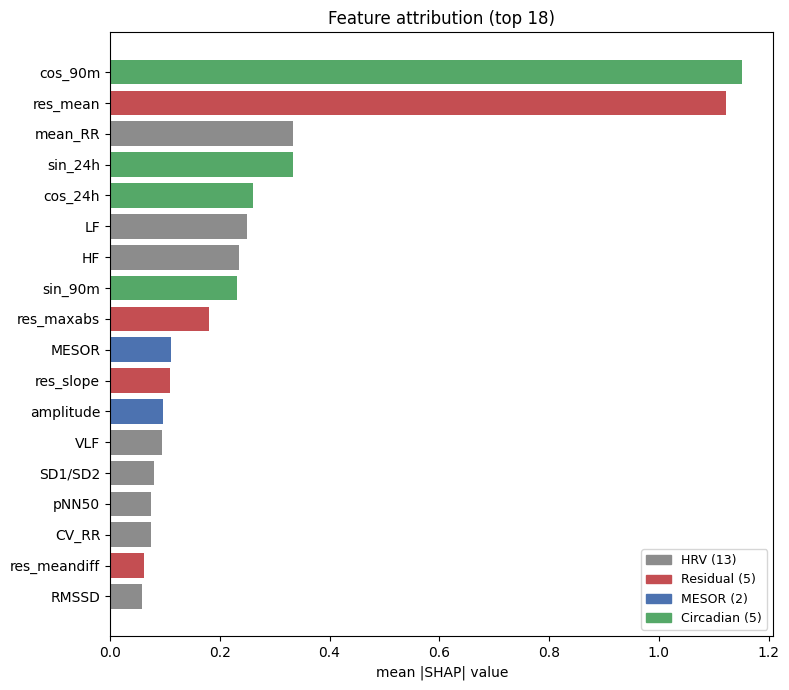


residual features in the top 10: 2 of 5
MESOR ranks 10 of 25 by attribution, yet contributes +0.007 causally.
A high SHAP rank with a low causal gain indicates a correlated feature that
others can substitute for when it is removed and the model retrained.


In [8]:
gof={}
for gname,idx in GROUPS.items():
    for i in idx: gof[i]=gname
order=np.argsort(imp)[::-1]

print(f"{'rank':<6}{'feature':<16}{'group':<15}{'mean |SHAP|':>12}")
print("-"*52)
for r,i in enumerate(order[:15],1):
    print(f"{r:<6}{FEATURE_NAMES[i]:<16}{gof[i]:<15}{imp[i]:>12.4f}")

fig,ax=plt.subplots(figsize=(8,7))
top=order[:18][::-1]
ax.barh([FEATURE_NAMES[i] for i in top],[imp[i] for i in top],
        color=[GROUP_COLOR[gof[i]] for i in top])
ax.set_xlabel('mean |SHAP| value'); ax.set_title('Feature attribution (top 18)')
handles=[plt.Rectangle((0,0),1,1,color=c) for c in GROUP_COLOR.values()]
ax.legend(handles,GROUP_COLOR.keys(),loc='lower right',fontsize=9)
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_shap_features.png',dpi=200,bbox_inches='tight'); plt.show()

resid_in_top10=sum(1 for i in order[:10] if gof[i]=='Residual (5)')
print(f"\nresidual features in the top 10: {resid_in_top10} of 5")
mesor_rank=[r for r,i in enumerate(order,1) if FEATURE_NAMES[i]=='MESOR'][0]
print(f"MESOR ranks {mesor_rank} of 25 by attribution, yet contributes +0.007 causally.")
print("A high SHAP rank with a low causal gain indicates a correlated feature that")
print("others can substitute for when it is removed and the model retrained.")

## 6. Attribution stability across subjects

Does the model rely on the same features for every person? Each subject's attribution vector is
ranked, and Spearman correlations are computed between every pair of subjects.

- **High agreement** supports a single population model: one feature set serves everyone.
- **Low agreement** means different people are classified using different evidence, which is a
  quantitative argument for personalisation.

ATTRIBUTION STABILITY ACROSS SUBJECTS
mean pairwise rank correlation : 0.922
sd                             : 0.032
range                          : [0.819, 0.989]

HIGH agreement -- the model uses the same evidence for everyone,
which supports the single population model.


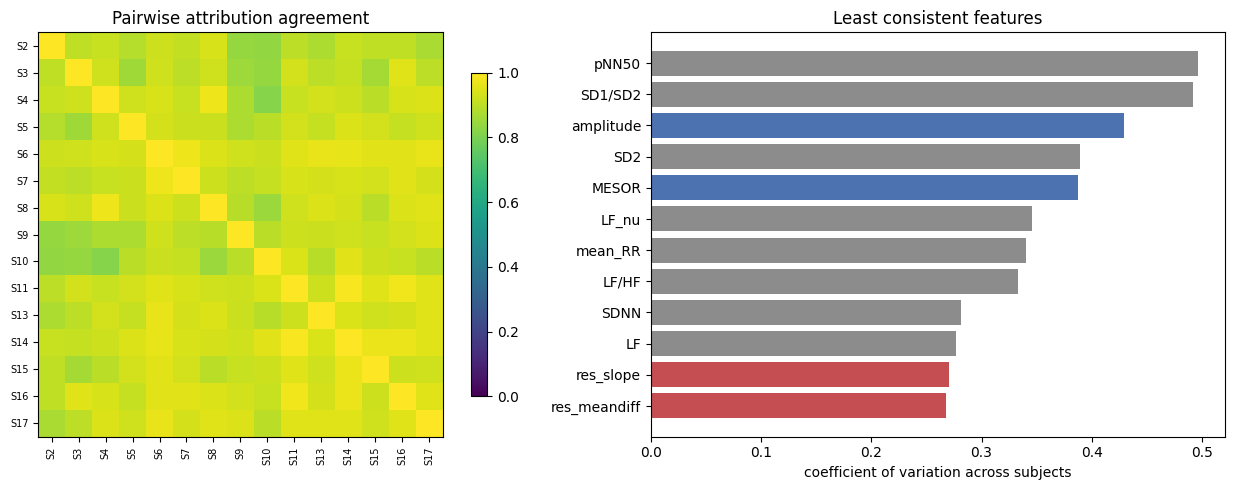


saved shap_per_subject.csv


In [9]:
subs=sorted(per_subject_imp)
M=np.stack([per_subject_imp[s] for s in subs])            # (15,25)
R=np.zeros((len(subs),len(subs)))
for i in range(len(subs)):
    for j in range(len(subs)):
        R[i,j]=spearmanr(M[i],M[j]).correlation
off=R[~np.eye(len(subs),dtype=bool)]

print("="*60); print("ATTRIBUTION STABILITY ACROSS SUBJECTS"); print("="*60)
print(f"mean pairwise rank correlation : {off.mean():.3f}")
print(f"sd                             : {off.std():.3f}")
print(f"range                          : [{off.min():.3f}, {off.max():.3f}]")
print()
m=off.mean()
if m>0.7:
    print("HIGH agreement -- the model uses the same evidence for everyone,")
    print("which supports the single population model.")
elif m>0.4:
    print("MODERATE agreement -- broadly shared, with per-subject variation.")
else:
    print("LOW agreement -- different subjects rely on different features,")
    print("which is a quantitative argument for personalisation.")

fig,ax=plt.subplots(1,2,figsize=(13,5))
im=ax[0].imshow(R,vmin=0,vmax=1,cmap='viridis')
ax[0].set_xticks(range(len(subs))); ax[0].set_yticks(range(len(subs)))
ax[0].set_xticklabels([f'S{s}' for s in subs],rotation=90,fontsize=7)
ax[0].set_yticklabels([f'S{s}' for s in subs],fontsize=7)
ax[0].set_title('Pairwise attribution agreement'); plt.colorbar(im,ax=ax[0],shrink=.8)

var=M.std(0)/(M.mean(0)+1e-12)
o2=np.argsort(var)[::-1][:12][::-1]
ax[1].barh([FEATURE_NAMES[i] for i in o2],[var[i] for i in o2],
           color=[GROUP_COLOR[gof[i]] for i in o2])
ax[1].set_xlabel('coefficient of variation across subjects')
ax[1].set_title('Least consistent features')
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_shap_stability.png',dpi=200,bbox_inches='tight'); plt.show()

pd.DataFrame(M,index=[f'S{s}' for s in subs],columns=FEATURE_NAMES)\
  .to_csv(f'{SAVE}/shap_per_subject.csv')
print("\nsaved shap_per_subject.csv")

## 7. Attribution by stress level

group                relaxed        mild    moderate        high
----------------------------------------------------------------
HRV (13)              0.0628      0.1400      0.0917      0.1267
Residual (5)          0.6263      0.1345      0.1759      0.2673
MESOR (2)             0.1374      0.0836      0.0221      0.1716
Circadian (5)         0.8504      0.2999      0.2655      0.1778


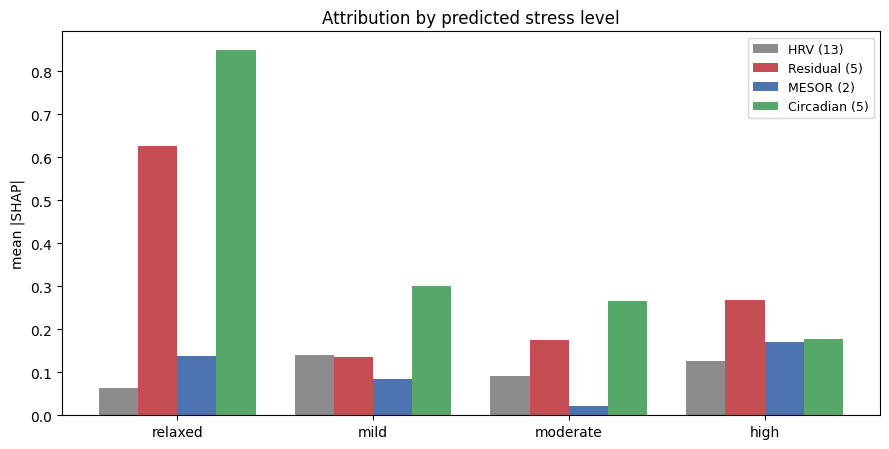


If residual attribution rises with stress level, the deviation signal is
doing more work precisely where the harder decisions are.


In [10]:
print(f"{'group':<16}"+"".join(f"{c:>12}" for c in CLASS_NAMES))
print("-"*64)
percls={}
for gname,idx in GROUPS.items():
    row=[np.abs(SHAP[:,idx,c]).mean() for c in range(NCLS)]
    percls[gname]=row
    print(f"{gname:<16}"+"".join(f"{v:>12.4f}" for v in row))

fig,ax=plt.subplots(figsize=(9,4.6))
w=0.2; xs=np.arange(NCLS)
for i,(gname,row) in enumerate(percls.items()):
    ax.bar(xs+i*w-1.5*w,row,w,label=gname,color=GROUP_COLOR[gname])
ax.set_xticks(xs); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('mean |SHAP|'); ax.set_title('Attribution by predicted stress level'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_shap_byclass.png',dpi=200,bbox_inches='tight'); plt.show()
print("\nIf residual attribution rises with stress level, the deviation signal is")
print("doing more work precisely where the harder decisions are.")

## 8. Reporting guidance

**State the relationship to the decomposition explicitly.** SHAP describes what one trained model
uses; the decomposition establishes what the model needs. Where they agree, the conclusion is
strengthened. Where they disagree — most plausibly MESOR ranking well by SHAP despite a +0.007
causal gain — the explanation is feature correlation, and that should be stated rather than glossed
over.

**Suggested wording:**

> "SHAP attribution over leave-one-subject-out folds assigns X% of total attribution to the residual
> block, against Y% for the Cosinor parameters, consistent with the causal decomposition in Table I.
> Attribution rankings agree across subjects with a mean pairwise Spearman correlation of Z,
> indicating the model relies on [a common / subject-varying] feature set."

**For the stability result.** A high mean correlation supports the single population model already
used. A low one is an argument for personalisation, and would sit alongside the existing finding
that class-balanced calibration yields +0.082.

**What this does not establish.** SHAP is descriptive. It cannot show that a feature is necessary,
only that the fitted model responds to it. No causal claim should rest on this section alone.

**Figures produced:** `fig_shap_groups.png` (group attribution — the main paper figure),
`fig_shap_features.png` (top individual features), `fig_shap_stability.png` (cross-subject
agreement), `fig_shap_byclass.png` (attribution per stress level).
